In [139]:
# Set workspace
import sys
import os
workspace_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Libraries

In [140]:
# Libraries
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Get data

In [141]:
# Config
years = [2024, 2025]

In [142]:
# Get local race results data for UTMB

# Dictionary | key = year
utmb_race_results_df_dict = dict()
for year in years:

    utmb_year_race_results_df = pd.read_parquet(
        os.path.join("..", "utmb_under_27h/data", f"utmb_{year}_race_results.parquet")
    )
    utmb_year_race_results_df = utmb_year_race_results_df.assign(year=year)

    print(f"Data for year {year} fetched and loaded successfully")
    utmb_race_results_df_dict[year] = utmb_year_race_results_df

# Single dataframe with all years
utmb_race_results_df = pd.concat(
    utmb_race_results_df_dict.values(),
    ignore_index=True
).reset_index(drop=True)

Data for year 2024 fetched and loaded successfully
Data for year 2025 fetched and loaded successfully


In [143]:
# Get sector data for UTMB

# Dictionary | key = year
utmb_sector_data_dict = dict()
for year in years:

    with open(os.path.join(f"data", f"utmb_{year}_sector_data.pkl"), "rb") as f:
        utmb_year_sector_data_dict = pickle.load(f)

    print(f"Data for year {year} fetched and loaded successfully")
    utmb_sector_data_dict[year] = utmb_year_sector_data_dict

Data for year 2024 fetched and loaded successfully
Data for year 2025 fetched and loaded successfully


Connect Race data & Sector data - Dict

In [144]:
# Dict((year, bib_number) -> sector data dataframe with race results information

runner_race_sector_data_dict = dict()
for year in years:
    utmb_race_results_year_df = utmb_race_results_df_dict[year]
    utmb_sector_data_year_dict = utmb_sector_data_dict[year]
 
    for bib_number in utmb_sector_data_year_dict.keys():
        utmb_race_results_year_bib_series = utmb_race_results_year_df.query("runner_bib_number == @bib_number").iloc[0]
        
        utmb_sector_data_year_bib_df = (
            utmb_sector_data_year_dict[bib_number]
            .assign(**utmb_race_results_year_bib_series.to_dict())
        )

        runner_race_sector_data_dict[(year, bib_number)] = utmb_sector_data_year_bib_df

In [145]:
# Full dataframe with all years and all runners and their sectors combined
dfs = []
for df in runner_race_sector_data_dict.values():
    if df is None or df.empty:
        continue
    dfs.append(df.dropna(axis=1, how="all"))

runner_race_sector_data_df = pd.concat(dfs, ignore_index=True)

# About data

Work on data

In [146]:
# Runner/Race/Year unique identifier - Runner ID
runner_race_sector_data_df = runner_race_sector_data_df.assign(
    runner_id = lambda x: x.groupby([
        "runner_bib_number",
        "race_id",
        "year",
    ]).ngroup() + 1
)

About data

In [147]:
# About data
print("About data:")
print("-------------------------------------")
print("Race IDs: {}".format(runner_race_sector_data_df["race_id"].unique()))
print("Race names: {}".format(runner_race_sector_data_df["race_name"].unique()))
print("Years: {}".format(runner_race_sector_data_df["year"].unique()))
print("Number of unique runners: {:,}".format(runner_race_sector_data_df["runner_url"].nunique()))
print("Number of unique Runner/Race/Year combinations: {:,}".format(runner_race_sector_data_df["runner_id"].nunique()))

About data:
-------------------------------------
Race IDs: ['utmb']
Race names: ['UTMB®']
Years: [2024 2025]
Number of unique runners: 5,058
Number of unique Runner/Race/Year combinations: 5,249


In [148]:
# About Sectors
print("\nAbout sectors:")
print("-------------------------------------")
print("Number of sector checpoints: {:,}".format(runner_race_sector_data_df["sector_checkpoint_id"].nunique()))
print("Sector checkpoint IDs: {}".format(runner_race_sector_data_df["sector_checkpoint_id"].unique().tolist()))

print("Do all races/years have the same number of sectors? {}".format(
    runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique().nunique() == 1
))

sector_sets = runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].apply(lambda s: frozenset(s.unique()))
print("Do all races/years have the same sector IDs? {}".format(
    sector_sets.nunique() == 1
))

expected_sector_count = runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique()
runner_sector_counts = runner_race_sector_data_df.groupby(["race_id", "year", "runner_bib_number"])["sector_checkpoint_id"].nunique()
print("Do all runners have all of the sectors? {}".format(
    runner_sector_counts.groupby(["race_id", "year"]).min().eq(expected_sector_count).all()
))


About sectors:
-------------------------------------
Number of sector checpoints: 28
Sector checkpoint IDs: [0, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 18, 19, 20, 22, 23, 24, 27, 30, 31, 33, 34, 35, 44, 144]
Do all races/years have the same number of sectors? False
Do all races/years have the same sector IDs? False
Do all runners have all of the sectors? True


Sector data work
- sector_race_time_at_checkpoint - formatted cumulative race time at sector (checkpoint) arrival
- sector_time_seconds - cumulative race time at sector (checkpoint) arrival
- sector_time - previous sector time (time for the segment that ended at this checkpoint) - excluding rest at the previous checkpoint.
- sector_rest_time / sector_rest_time_seconds - checkpoint stop time, but some rows may be special rest-only checkpoint rows.
- Row (j) means sector from previous checkpoint to current checkpoint and not sector starting at current checkpoint

In [149]:
# Sector data display 
sector_cols = runner_race_sector_data_df.columns[
    runner_race_sector_data_df.columns.str.contains("sector")
]
runner_race_sector_data_df.loc[:, ["runner_id"] + sector_cols.tolist()]

,runner_id,sector_checkpoint_id,sector_arrival_time,sector_departure_time,sector_rest_time_seconds,sector_speed_kmh,sector_pace_min_per_km,sector_time_seconds,sector_time,sector_race_time_at_checkpoint,sector_checkpoint_rank,sector_checkpoint_rank_change,sector_predicted_time,sector_rest_time
0,1,0,None,2024-08-30T16:01:52.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,2024-08-30T17:14:33.620Z,2024-08-30T17:14:33.620Z,NaN,10.89,5.51,4361.62,1:12:42,1:12:42,21.0,NaN,NaN,NaN
2,1,3,2024-08-30T17:54:10.170Z,2024-08-30T17:54:10.170Z,NaN,12.86,4.67,6738.17,0:39:37,1:52:18,26.0,5.0,2024-08-30T18:00:04.000Z,NaN
3,1,4,2024-08-30T18:48:40.530Z,2024-08-30T18:48:40.530Z,NaN,10.63,5.64,10008.53,0:54:30,2:46:49,18.0,-8.0,2024-08-30T18:50:34.000Z,NaN
4,1,5,2024-08-30T19:11:01.290Z,2024-08-30T19:11:01.290Z,NaN,11.49,5.22,11349.29,0:22:21,3:09:09,17.0,-1.0,2024-08-30T19:11:34.000Z,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141989,4917,33,2025-08-30T22:32:33.000Z,2025-08-30T22:32:33.000Z,NaN,2.90,20.67,110853.00,1:22:41,30:47:33,556.0,-37.0,2025-08-30T22:29:48.000Z,NaN
141990,4917,34,2025-08-31T00:30:10.000Z,2025-08-31T00:30:10.000Z,NaN,4.15,14.45,117910.00,1:57:37,32:45:10,561.0,5.0,2025-08-31T00:18:22.000Z,NaN
141991,4917,35,2025-08-31T00:44:09.000Z,2025-08-31T00:44:09.000Z,839.0,NaN,NaN,118749.00,0:13:59,32:59:09,566.0,5.0,2025-08-31T00:30:10.000Z,0:13:59
141992,4917,44,2025-08-31T04:25:06.000Z,2025-08-31T04:25:06.000Z,NaN,3.06,19.59,132006.00,3:40:57,36:40:06,563.0,-3.0,2025-08-31T04:07:09.000Z,NaN


In [150]:
# Sector diagnostic

sector_clean_check_df = (
    runner_race_sector_data_df
    .sort_values(["runner_id", "sector_checkpoint_id"])
    .assign(
        sector_arrival_time_dt=lambda df: pd.to_datetime(df["sector_arrival_time"], errors="coerce"),
        sector_departure_time_dt=lambda df: pd.to_datetime(df["sector_departure_time"], errors="coerce"),

        previous_sector_checkpoint_id=lambda df: (
            df.groupby("runner_id")["sector_checkpoint_id"].shift(1)
        ),
        previous_sector_arrival_time_dt=lambda df: (
            df.groupby("runner_id")["sector_arrival_time_dt"].shift(1)
        ),
        previous_sector_departure_time_dt=lambda df: (
            df.groupby("runner_id")["sector_departure_time_dt"].shift(1)
        ),

        sector_time_from_field_seconds=lambda df: (
            pd.to_timedelta(df["sector_time"]).dt.total_seconds()
        ),
        sector_race_time_at_checkpoint_seconds=lambda df: (
            pd.to_timedelta(df["sector_race_time_at_checkpoint"]).dt.total_seconds()
        ),
        sector_time_from_cumulative_diff_seconds=lambda df: (
            df.groupby("runner_id")["sector_time_seconds"].diff()
        ),
        sector_time_from_arrival_diff_seconds=lambda df: (
            df["sector_arrival_time_dt"] - df["previous_sector_arrival_time_dt"]
        ).dt.total_seconds(),
        sector_time_from_previous_departure_seconds=lambda df: (
            df["sector_arrival_time_dt"] - df["previous_sector_departure_time_dt"]
        ).dt.total_seconds(),
        sector_rest_time_from_field_seconds=lambda df: (
            pd.to_timedelta(df["sector_rest_time"]).dt.total_seconds()
        ),
        sector_rest_time_from_timestamp_seconds=lambda df: (
            df["sector_departure_time_dt"] - df["sector_arrival_time_dt"]
        ).dt.total_seconds(),
    )
)

display(
    sector_clean_check_df[
        [
            "runner_id",
            "previous_sector_checkpoint_id",
            "sector_checkpoint_id",
            "sector_arrival_time",
            "sector_departure_time",
            "sector_time",
            "sector_time_seconds",
            "sector_time_from_field_seconds",
            "sector_time_from_cumulative_diff_seconds",
            "sector_time_from_arrival_diff_seconds",
            "sector_time_from_previous_departure_seconds",
            "sector_rest_time",
            "sector_rest_time_seconds",
            "sector_rest_time_from_field_seconds",
            "sector_rest_time_from_timestamp_seconds",
        ]
    ].head(40)
)

sector_clean_check_summary_df = (
    sector_clean_check_df
    .assign(
        diff_field_vs_cumulative_diff=lambda df: (
            df["sector_time_from_field_seconds"]
            - df["sector_time_from_cumulative_diff_seconds"]
        ),
        diff_field_vs_arrival_diff=lambda df: (
            df["sector_time_from_field_seconds"]
            - df["sector_time_from_arrival_diff_seconds"]
        ),
        diff_field_vs_previous_departure=lambda df: (
            df["sector_time_from_field_seconds"]
            - df["sector_time_from_previous_departure_seconds"]
        ),
        diff_rest_field_vs_timestamp=lambda df: (
            df["sector_rest_time_from_field_seconds"]
            - df["sector_rest_time_from_timestamp_seconds"]
        ),
    )
    [
        [
            "diff_field_vs_cumulative_diff",
            "diff_field_vs_arrival_diff",
            "diff_field_vs_previous_departure",
            "diff_rest_field_vs_timestamp",
        ]
    ]
    .describe()
)

display(sector_clean_check_summary_df)

,runner_id,previous_sector_checkpoint_id,sector_checkpoint_id,sector_arrival_time,sector_departure_time,sector_time,sector_time_seconds,sector_time_from_field_seconds,sector_time_from_cumulative_diff_seconds,sector_time_from_arrival_diff_seconds,sector_time_from_previous_departure_seconds,sector_rest_time,sector_rest_time_seconds,sector_rest_time_from_field_seconds,sector_rest_time_from_timestamp_seconds
0,1,NaN,0,None,2024-08-30T16:01:52.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0.0,2,2024-08-30T17:14:33.620Z,2024-08-30T17:14:33.620Z,1:12:42,4361.62,4362.0,NaN,NaN,4361.62,NaN,NaN,NaN,0.000
2,1,2.0,3,2024-08-30T17:54:10.170Z,2024-08-30T17:54:10.170Z,0:39:37,6738.17,2377.0,2376.55,2376.55,2376.55,NaN,NaN,NaN,0.000
3,1,3.0,4,2024-08-30T18:48:40.530Z,2024-08-30T18:48:40.530Z,0:54:30,10008.53,3270.0,3270.36,3270.36,3270.36,NaN,NaN,NaN,0.000
4,1,4.0,5,2024-08-30T19:11:01.290Z,2024-08-30T19:11:01.290Z,0:22:21,11349.29,1341.0,1340.76,1340.76,1340.76,NaN,NaN,NaN,0.000
5,1,5.0,6,2024-08-30T19:46:31.590Z,2024-08-30T19:46:31.590Z,0:35:30,13479.59,2130.0,2130.30,2130.30,2130.30,NaN,NaN,NaN,0.000
6,1,6.0,7,2024-08-30T20:44:16.000Z,2024-08-30T20:44:16.000Z,0:57:44,16944.00,3464.0,3464.41,3464.41,3464.41,NaN,NaN,NaN,0.000
7,1,7.0,8,2024-08-30T21:09:39.110Z,2024-08-30T21:12:02.040Z,0:25:23,18467.11,1523.0,1523.11,1523.11,1523.11,0:02:23,142.93,143.0,142.930
8,1,8.0,9,2024-08-30T22:42:06.000Z,2024-08-30T22:42:06.000Z,1:30:04,24014.00,5404.0,5546.89,5546.89,5403.96,NaN,NaN,NaN,0.000
9,1,9.0,11,2024-08-30T23:34:43.550Z,2024-08-30T23:34:43.550Z,0:52:38,27171.55,3158.0,3157.55,3157.55,3157.55,NaN,NaN,NaN,0.000


,diff_field_vs_cumulative_diff,diff_field_vs_arrival_diff,diff_field_vs_previous_departure,diff_rest_field_vs_timestamp
count,105743.000000,105743.000000,110929.000000,30151.000000
mean,-251.854165,-251.854165,0.002423,462.531017
std,700.710572,700.710572,0.212303,1073.040192
min,-16420.940000,-16420.940000,-0.490000,-0.490000
25%,-0.460000,-0.460000,-0.030000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.040000,24.000000
max,0.500000,0.500000,0.500000,12701.000000


In [151]:
# Clean sector data columns

runner_race_sector_data_df = (
    runner_race_sector_data_df
    .sort_values(["runner_id", "sector_checkpoint_id"])
    .assign(

        # Checkpoint timing
        sector_arrival_time_dt = lambda df: pd.to_datetime(
            df["sector_arrival_time"],
            errors="coerce",
        ),
        sector_departure_time_dt = lambda df: pd.to_datetime(
            df["sector_departure_time"],
            errors="coerce",
        ),

        # Cumulative race time at checkpoint arrival
        sector_race_time_at_checkpoint_min = lambda df: (
            df["sector_time_seconds"] / 60
        ),

        # Movement-ish time: previous checkpoint departure -> current checkpoint arrival
        sector_time_moving_min = lambda df: (
            pd.to_timedelta(df["sector_time"]).dt.total_seconds() / 60
        ),

        # Race-clock elapsed time: previous checkpoint arrival -> current checkpoint arrival
        # This includes rest at the previous checkpoint.
        sector_time_elapsed_min = lambda df: (
            (df.groupby("runner_id")["sector_time_seconds"].diff() / 60).fillna(df["sector_time_moving_min"])
        ),

        # Rest/stop time at checkpoint
        sector_rest_time_min = lambda df: (
            (pd.to_timedelta(df["sector_rest_time"]).dt.total_seconds() / 60).fillna(0)
        ),
    )
    .assign(
        # Rest at previous checkpoint + movement into current checkpoint
        sector_time_full_start_rest_min = lambda df: (
            df.groupby("runner_id")["sector_rest_time_min"].shift(1).fillna(0) + df["sector_time_moving_min"]
        ),
        # Movement into current checkpoint + rest at current checkpoint
        sector_time_full_end_rest_min = lambda df: (
            df["sector_time_moving_min"] + df["sector_rest_time_min"]
        ),
        # Movement only: previous checkpoint departure -> current checkpoint arrival
        sector_time_full_no_rest_min = lambda df: (
            df["sector_time_moving_min"]
        )
    )
    .assign(
        # Useful rest share feature
        sector_rest_time_share_start_rest = lambda df: (
            df["sector_rest_time_min"] / df["sector_time_full_start_rest_min"]
        ),
        sector_rest_time_end_share = lambda df: (
            df["sector_rest_time_min"] / df["sector_time_full_end_rest_min"]
        ),
    )
    .assign(
        # Sector distance [km]
        sector_distance_km = lambda df: (
            df["sector_time_moving_min"] / df["sector_pace_min_per_km"]
        )
    )
    # Remove start rows
    .loc[lambda df: df["sector_time_moving_min"].notna()]
    .reset_index(drop=True)
)

Sector rows are arrival-based:
- Each row describes the segment from the previous checkpoint to this checkpoint.
- sector_time_moving_min - previous checkpoint departure -> current checkpoint arrival (excludes rest at the previous checkpoint)
- sector_time_elapsed_min - previous checkpoint arrival -> current checkpoint arrival (includes rest at the previous checkpoint plus movement to current checkpoint)
- sector_rest_time_min - current checkpoint arrival -> current checkpoint departure (rest/stop time at the current checkpoint)
- row with sector_checkpoint_id = 9 describes the segment: previous checkpoint -> checkpoint 9

Rests:
- arrival_time - when runner reaches the checkpoint/hut
- departure_time - when runner leaves the checkpoint/hut
- rest_time - departure_time - arrival_time
- the runner “goes through” the checkpoint at arrival, then may rest, then departs
- for row j:
    - previous checkpoint departure -> current checkpoint arrival --> sector_time_moving_min
    - current checkpoint arrival -> current checkpoint departure --> sector_rest_time_min

Where do we assign the rest time analytically?
- a) rest belongs to the sector ending - the sector includes arriving at the rest stop and dealing with the rest stop before continuing [sector_full_time_current_rest = sector_time_moving_min + sector_rest_time_min]
- b) rest belongs to the next sector - full sector j+1 = rest at checkpoint j + movement from checkpoint j to checkpoint j+1 [sector_time_elapsed_min = previous checkpoint rest + movement into current checkpoint]
- c) only moving time without rest tme

Use:
- sector_time_moving_min as the main movement-sector time, 
- sector_time_elapsed_min if rest at the previous checkpoint should count, 
- and sector_rest_time_min/share as separate rest-strategy features.

Other data work

In [152]:
# Sector IDs: 1-max, not "random" values (Race/Year specific)
runner_race_sector_data_df = (
    runner_race_sector_data_df
    .assign(
        sector_number = lambda x: x
        .groupby(["race_id", "year"])["sector_checkpoint_id"]
        .rank(method="dense", ascending=True)
        .astype(int)
    )
)

# Sanity check
check_df = (
    runner_race_sector_data_df[["race_id", "year", "sector_checkpoint_id", "sector_number"]]
    .drop_duplicates()
)

assert (
    check_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique()
    == check_df.groupby(["race_id", "year"])["sector_number"].nunique()
).all(), "Sector checkpoint mapping is not 1-to-1 within at least one race/year."

assert (
    check_df.groupby(["race_id", "year"])["sector_number"].min() == 1
).all(), "Sector checkpoint numbering does not start at 1 for at least one race/year."

# Assign to original column name
# runner_race_sector_data_df = (
#     runner_race_sector_data_df
#     .assign(sector_checkpoint_id = lambda x: x["sector_number"])
#     .drop(columns=["sector_number"])
# )

In [153]:
# How are DNF runners represented after their final reached checkpoint? --> They have missing values for all sectors after DNF race time
runner_race_sector_data_dnf_df = runner_race_sector_data_df.loc[~runner_race_sector_data_df["runner_is_finisher"]].reset_index(drop=True).copy()
runner_race_sector_data_finisher_df = runner_race_sector_data_df.loc[runner_race_sector_data_df["runner_is_finisher"]].reset_index(drop=True).copy()

# Race Time Normalization - Finishers

Estimate expected runner race time based on UTMB index & Race year: T ~ UTMB_index + Race_year + UTMB_index:Race_year

In [154]:
# Data - one row per runner/year
df_race_time_normalization_estimation = (
    runner_race_sector_data_finisher_df
    .drop_duplicates(subset=["runner_id"])
    [["runner_id", "runner_race_time_hours", "runner_overall_index", "year"]]
    .dropna(how="any")
    .reset_index(drop=True)
    .copy()
)

In [155]:
# Model - Fit & Predict

# Fit 
model_race_time_norm = smf.ols(
    formula = "runner_race_time_hours ~ runner_overall_index * C(year)",
    data = df_race_time_normalization_estimation,
)
fit_race_time_norm = model_race_time_norm.fit()

# Predict & store predictions
y_pred_race_time_norm = fit_race_time_norm.predict(df_race_time_normalization_estimation)
df_race_time_normalization_estimation["runner_race_time_hours_pred"] = y_pred_race_time_norm

In [156]:
# Coefficients
coef_race_time_norm_df = (
    pd.DataFrame({
        "coef": fit_race_time_norm.params,
        "std_err": fit_race_time_norm.bse,
        "p_value": fit_race_time_norm.pvalues,
        "ci_lower": fit_race_time_norm.conf_int()[0],
        "ci_upper": fit_race_time_norm.conf_int()[1],
    })
    .reset_index(names="term")
)

coef_race_time_norm_df

,term,coef,std_err,p_value,ci_lower,ci_upper
0,Intercept,69.630598,0.480596,0.000000,68.688313,70.572884
1,C(year)[T.2025],0.034116,0.677748,0.959856,-1.294717,1.362949
2,runner_overall_index,-0.053391,0.000827,0.000000,-0.055014,-0.051769
3,runner_overall_index:C(year)[T.2025],-0.000431,0.001177,0.714486,-0.002738,0.001877


Model diagnostics

In [157]:
# Calculate absolute race time residual: Expected - Actual
df_race_time_normalization_estimation = (
    df_race_time_normalization_estimation
    .assign(
        runner_race_time_hours_residual_abs = lambda df: (
            df["runner_race_time_hours_pred"] - df["runner_race_time_hours"]
        )
    )
)

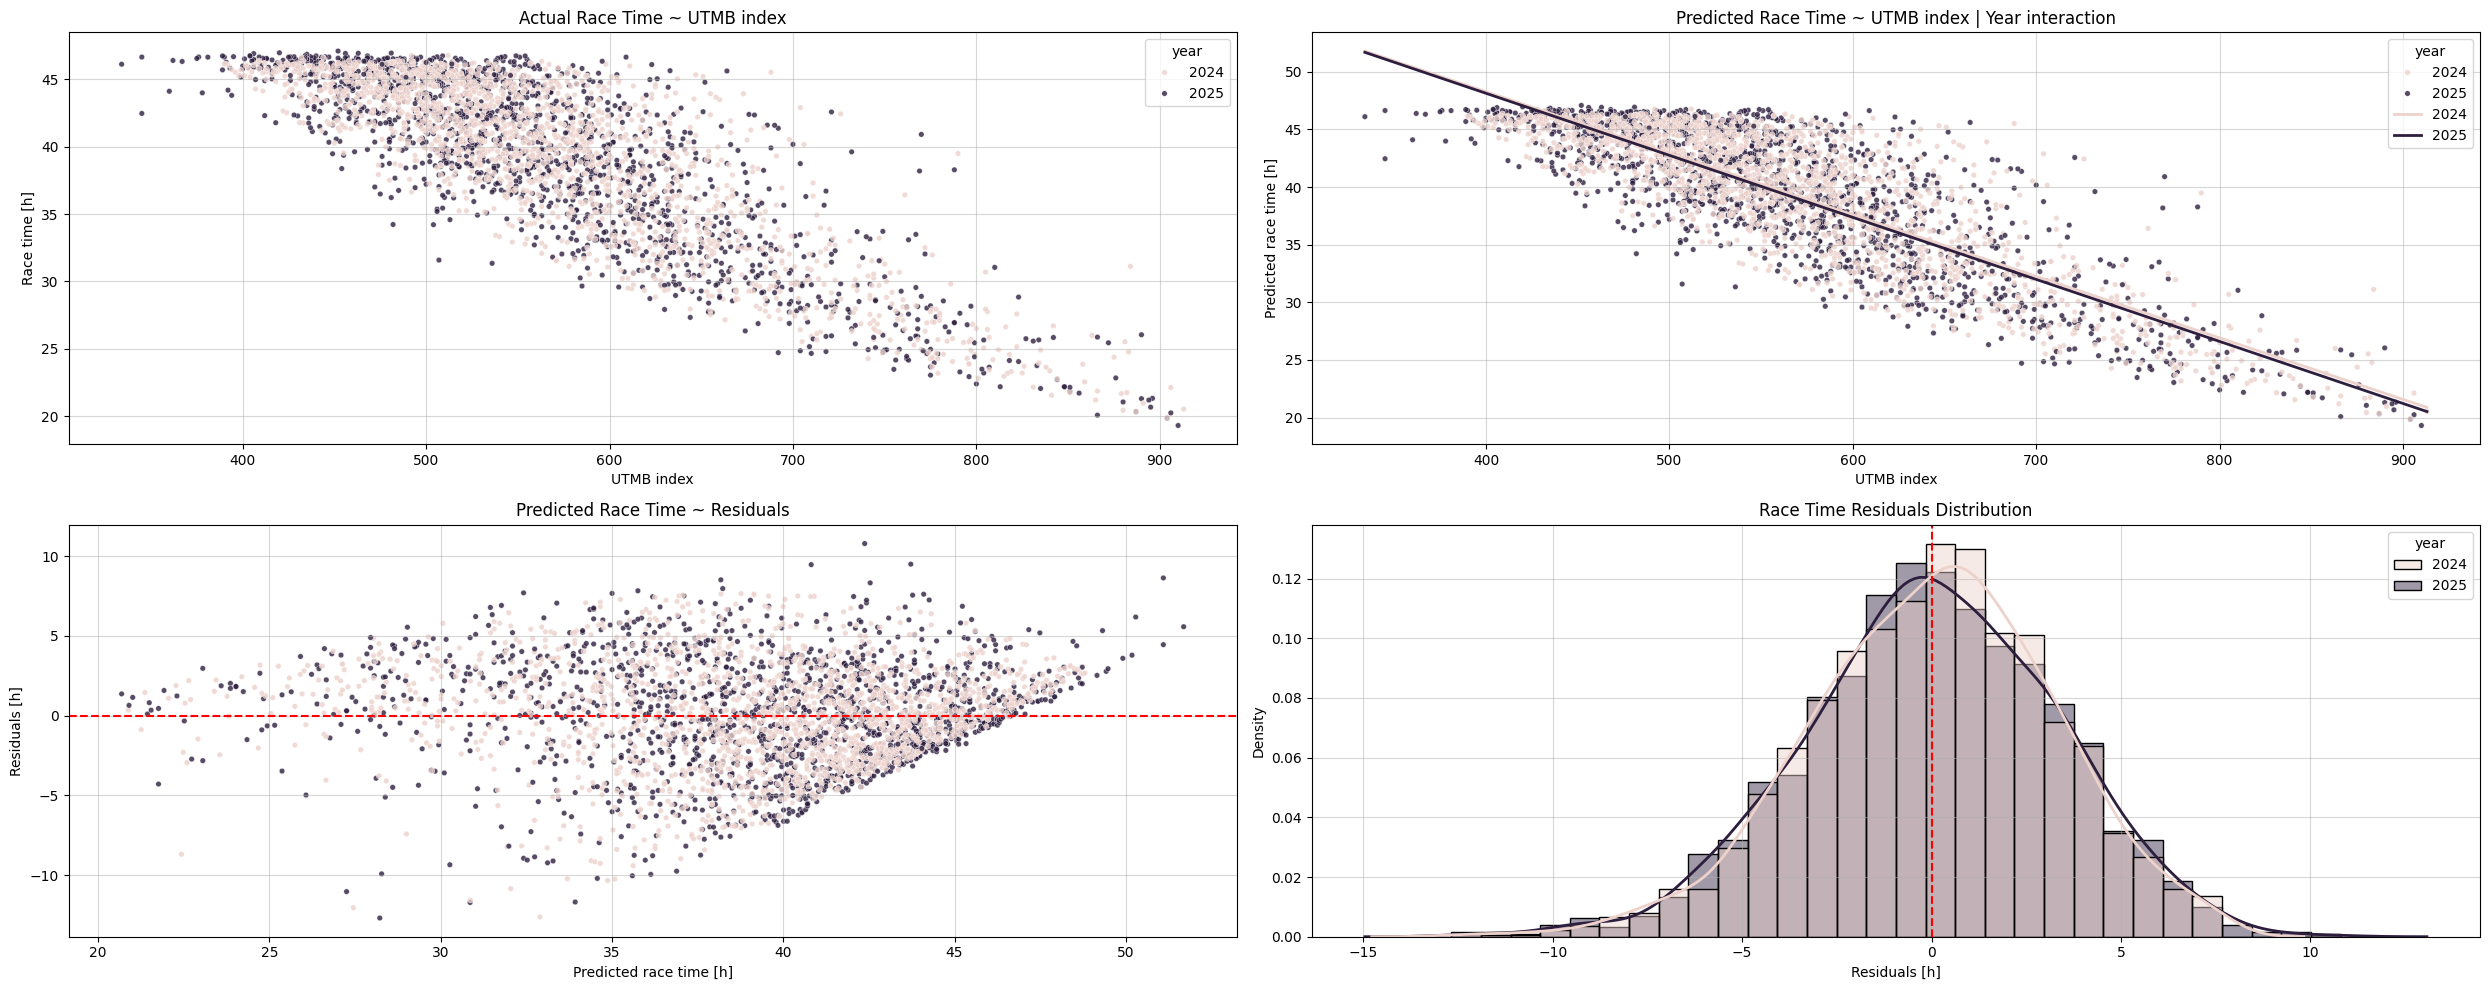

In [158]:
# Model diagnostic

fig, ax = plt.subplots(2, 2, figsize=(25, 10))

# Prediction grid for model lines
utmb_index_grid = np.linspace(
    df_race_time_normalization_estimation["runner_overall_index"].min(),
    df_race_time_normalization_estimation["runner_overall_index"].max(),
    100,
)

pred_grid_df = pd.concat(
    [
        pd.DataFrame({
            "runner_overall_index": utmb_index_grid,
            "year": year,
        })
        for year in sorted(df_race_time_normalization_estimation["year"].unique())
    ],
    ignore_index=True,
)

pred_grid_df = pred_grid_df.assign(
    runner_race_time_hours_pred=fit_race_time_norm.predict(pred_grid_df)
)

# Actual Race Time ~ UTMB index
ax[0, 0].set_title("Actual Race Time ~ UTMB index")
sns.scatterplot(
    data=df_race_time_normalization_estimation,
    x="runner_overall_index",
    y="runner_race_time_hours",
    hue="year",
    # color="black",
    s=16,
    alpha=0.8,
    ax=ax[0, 0],
)
ax[0, 0].set_xlabel("UTMB index")
ax[0, 0].set_ylabel("Race time [h]")

# Model prediction lines by year
ax[0, 1].set_title("Predicted Race Time ~ UTMB index | Year interaction")
sns.scatterplot(
    data=df_race_time_normalization_estimation,
    x="runner_overall_index",
    y="runner_race_time_hours",
    hue="year",
    s=16,
    alpha=0.8,
    ax=ax[0, 1],
)
sns.lineplot(
    data=pred_grid_df,
    x="runner_overall_index",
    y="runner_race_time_hours_pred",
    hue="year",
    # color="black",
    linewidth=2,
    ax=ax[0, 1],
)
ax[0, 1].set_xlabel("UTMB index")
ax[0, 1].set_ylabel("Predicted race time [h]")

# Predicted values vs. residuals
ax[1, 0].set_title("Predicted Race Time ~ Residuals")
sns.scatterplot(
    data=df_race_time_normalization_estimation,
    x="runner_race_time_hours_pred",
    y="runner_race_time_hours_residual_abs",
    hue="year",
    # color="black",
    s=16,
    alpha=0.8,
    ax=ax[1, 0],
    legend=False,
)
ax[1, 0].axhline(0, color="red", linestyle="--")
ax[1, 0].set_xlabel("Predicted race time [h]")
ax[1, 0].set_ylabel("Residuals [h]")

# Residuals distribution
ax[1, 1].set_title("Race Time Residuals Distribution")
sns.histplot(
    data=df_race_time_normalization_estimation,
    x="runner_race_time_hours_residual_abs",
    hue="year",
    # color="black",
    bins=30,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax[1, 1],
)
sns.kdeplot(
    data=df_race_time_normalization_estimation,
    x="runner_race_time_hours_residual_abs",
    hue="year",
    # color="black",
    common_norm=False,
    linewidth=2,
    ax=ax[1, 1],
    legend=False,
)
ax[1, 1].axvline(0, color="red", linestyle="--")
ax[1, 1].set_xlabel("Residuals [h]")
ax[1, 1].set_ylabel("Density")

for i in [0, 1]:
    for j in [0, 1]:
        ax[i, j].grid(alpha=0.5)

plt.tight_layout()
plt.show()

Race time normalization
- Absolute residual: Expected race time - Actual race time 
    - 0.5 -> runner was 0.5 hours faster than expected
- Relative residual: 1 - Actual race time / Expected race time
    - 0.05 -> runner was 5% faster than expected
- Percentile residual: 1 - Relative residual ranked by percentages
    - 0.9 -> runner performed better than 90% of field, relative expectation

In [159]:
# Normalize race times - Residual based
df_race_time_normalization_estimation = (
    df_race_time_normalization_estimation
    .assign(
        runner_race_time_hours_residual_prc = lambda df: (
           1 - df["runner_race_time_hours"] / df["runner_race_time_hours_pred"]
        ),
        runner_race_time_performance_score = lambda df: (
            df["runner_race_time_hours_residual_prc"].rank(pct=True)
        )
    )
)



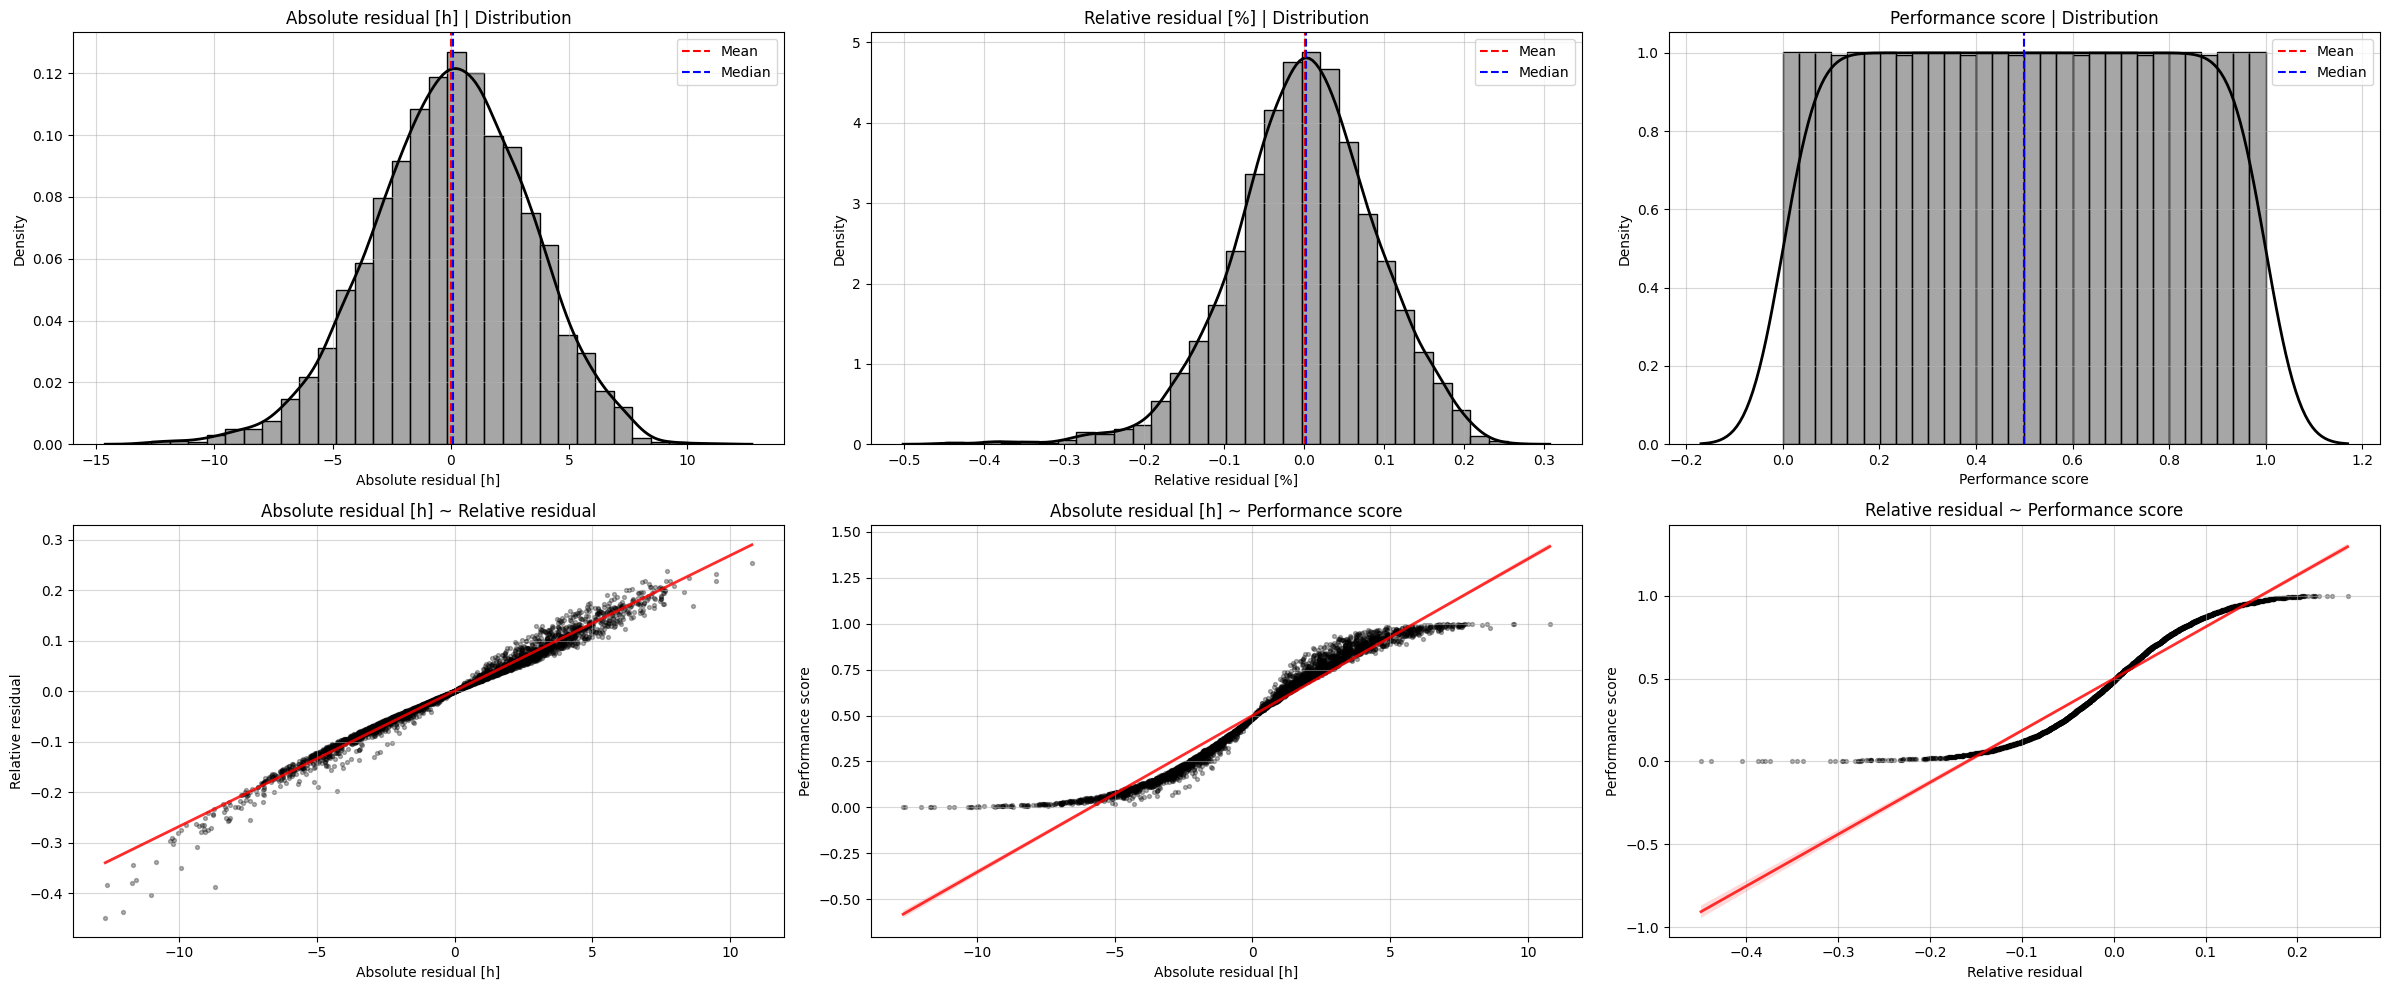

In [160]:
# Race time normalization diagnostics

plot_cols = [
    "runner_race_time_hours_residual_abs",
    "runner_race_time_hours_residual_prc",
    "runner_race_time_performance_score",
]

plot_titles = [
    "Absolute residual [h]",
    "Relative residual [%]",
    "Performance score",
]

scatter_pairs = [
    (
        "runner_race_time_hours_residual_abs",
        "runner_race_time_hours_residual_prc",
        "Absolute residual [h]",
        "Relative residual",
    ),
    (
        "runner_race_time_hours_residual_abs",
        "runner_race_time_performance_score",
        "Absolute residual [h]",
        "Performance score",
    ),
    (
        "runner_race_time_hours_residual_prc",
        "runner_race_time_performance_score",
        "Relative residual",
        "Performance score",
    ),
]

fig, ax = plt.subplots(2, 3, figsize=(24, 10))

# Top row: distributions
for i, (col, title) in enumerate(zip(plot_cols, plot_titles)):
    sns.histplot(
        data=df_race_time_normalization_estimation,
        x=col,
        bins=30,
        stat="density",
        color="grey",
        edgecolor="black",
        alpha=0.7,
        ax=ax[0, i],
    )
    sns.kdeplot(
        data=df_race_time_normalization_estimation,
        x=col,
        color="black",
        linewidth=2,
        ax=ax[0, i],
    )

    ax[0, i].axvline(
        df_race_time_normalization_estimation[col].mean(),
        color="red",
        linestyle="--",
        label="Mean",
    )
    ax[0, i].axvline(
        df_race_time_normalization_estimation[col].median(),
        color="blue",
        linestyle="--",
        label="Median",
    )

    ax[0, i].set_title(f"{title} | Distribution")
    ax[0, i].set_xlabel(title)
    ax[0, i].set_ylabel("Density")
    ax[0, i].legend()

# Bottom row: relationships with actual race time
for i, (x_col, y_col, x_label, y_label) in enumerate(scatter_pairs):
    sns.regplot(
        data=df_race_time_normalization_estimation,
        x=x_col,
        y=y_col,
        scatter_kws={"color": "black", "s": 8, "alpha": 0.3},
        line_kws={"color": "red", "linewidth": 2, "alpha": 0.8},
        ax=ax[1, i],
    )

    ax[1, i].set_title(f"{x_label} ~ {y_label}")
    ax[1, i].set_xlabel(x_label)
    ax[1, i].set_ylabel(y_label)

for i in [0, 1]:
    for j in [0, 1, 2]:
        ax[i, j].grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [161]:
# Merge back normalized race times to Finishers race time data
runner_race_sector_data_finisher_df = (
    runner_race_sector_data_finisher_df
    .merge(
        df_race_time_normalization_estimation[["runner_id", "runner_race_time_hours_residual_abs", "runner_race_time_hours_residual_prc", "runner_race_time_performance_score"]],
        on = "runner_id",
        how = "left",
    )
    .rename(columns={
        "runner_race_time_hours_residual_abs": "runner_race_time_hours_residual",
        "runner_race_time_hours_residual_prc": "runner_race_time_normalized",
        "runner_race_time_performance_score": "runner_rank_normalized",
    })
)


# Sector Time Normalization - Finishers

What do we consider as sector time?
- a) movement into current checkpoint + rest at current checkpoint [sector_time_full_end_rest_min]
- b) previous checkpoint rest + movement into current checkpoint [sector_time_full_start_rest_min]
- c) movement only [sector_time_full_no_rest_min]

Decision: movement only [sector_time_full_no_rest_min]
- It measures movement from previous checkpoint departure to current checkpoint arrival.
- It is the cleanest signal for "how fast did the runner move through this sector?"
- Then we can analyze sector_rest_time_min separately as a rest/pacing strategy feature.
- Then we can also run a sensitivy version with: movement into current checkpoint + rest at current checkpoint [sector_time_full_end_rest_min]

Notes:
- Different years have different checkpoint ID 
    - We assigned sector_number {1,2, ..., N} within race/year.
    - sector_number - means relative order of sectors in that race/year

In [163]:
# Race/Year sector times analysis

for (race_id, year), race_year_df in (
    runner_race_sector_data_df
    .sort_values(["race_id", "year", "sector_number"])
    .groupby(["race_id", "year"])
):
    sector_summary_df = (
        race_year_df
        .groupby("sector_number")
        .agg(
            sector_checkpoint_id = ("sector_checkpoint_id", "first"),
            n_runners = ("runner_id", "nunique"),
            distance_km = ("sector_distance_km", "first"),
            avg_movement_time_min = ("sector_time_full_no_rest_min", "mean"),
            avg_rest_time_min = ("sector_rest_time_min", "mean"),
        )
        .reset_index()
        .sort_values("sector_number")
    )

    print(f"Race/Year: {race_id} / {year}")
    print("-" * 60)
    print(f"- Number of sectors: {sector_summary_df['sector_number'].nunique():,}")
    print(f"- Number of runners: {race_year_df['runner_id'].nunique():,}")
    display(sector_summary_df)

    # print("- Average sector times:")
    # for _, row in sector_summary_df.iterrows():
    #     print("     - Sector {}".format(row["sector_number"]))
    #     print("         - Distance {:,.1f}".format(row["distance_km"]))
    #     print("         - Movement {:,.1f}".format(row["avg_movement_time_min"]))
    #     print("         - Rest {:,.1f}".format(row["avg_rest_time_min"]))
    #     print("         - Runners {:,.1f}".format(row["n_runners"]))
    print()

Race/Year: utmb / 2024
------------------------------------------------------------
- Number of sectors: 27
- Number of runners: 2,754


,sector_number,sector_checkpoint_id,n_runners,distance_km,avg_movement_time_min,avg_rest_time_min
0,1,2,2754,13.194192,111.814966,0.000000
1,2,3,2746,8.483226,63.676772,0.049800
2,3,4,2708,9.663121,94.505385,3.945249
3,4,5,2628,4.281609,40.783834,0.044026
4,5,6,2617,4.371921,62.466769,0.055878
5,6,7,2597,5.831650,98.329727,0.003523
6,7,8,2597,5.277200,43.951425,15.557059
7,8,9,2516,10.786427,143.553935,0.075523
8,9,11,2517,7.330548,94.990319,1.297040
9,10,12,2420,4.000328,73.724449,0.001784



Race/Year: utmb / 2025
------------------------------------------------------------
- Number of sectors: 25
- Number of runners: 2,488


,sector_number,sector_checkpoint_id,n_runners,distance_km,avg_movement_time_min,avg_rest_time_min
0,1,2,2481,14.558911,123.756966,0.000000
1,2,3,2484,8.486667,62.684125,0.065251
2,3,4,2465,9.659643,90.363908,0.324895
3,4,6,2395,8.635332,107.523653,0.480752
4,5,7,2365,5.831866,104.091374,0.394503
5,6,8,2389,5.275974,58.635559,16.956690
6,7,9,2112,10.784771,145.265507,0.013479
7,8,11,2252,4.872931,57.989195,2.840690
8,9,12,2202,3.990798,74.654829,0.001711
9,10,13,2194,4.587227,45.647600,0.133918


In [ ]:
runner_race_sector_data_finisher_df.loc[:, runner_race_sector_data_finisher_df.columns.str.contains("sector")]

,sector_checkpoint_id,sector_arrival_time,sector_departure_time,sector_rest_time_seconds,sector_speed_kmh,sector_pace_min_per_km,sector_time_seconds,sector_time,sector_race_time_at_checkpoint,sector_checkpoint_rank,...,sector_departure_time_dt,sector_race_time_at_checkpoint_min,sector_time_moving_min,sector_time_elapsed_min,sector_rest_time_min,sector_time_full_start_rest_min,sector_time_full_end_rest_min,sector_time_full_no_rest_min,sector_rest_time_share_start_rest,sector_rest_time_end_share
0,0,2024-08-30T17:14:33.620Z,2024-08-30T17:14:33.620Z,NaN,10.89,5.51,4361.62,1:12:42,1:12:42,21.0,...,2024-08-30 17:14:33.620000+00:00,72.693667,72.700000,72.700000,0.0,72.700000,72.700000,72.700000,0.0,0.0
1,1,2024-08-30T17:54:10.170Z,2024-08-30T17:54:10.170Z,NaN,12.86,4.67,6738.17,0:39:37,1:52:18,26.0,...,2024-08-30 17:54:10.170000+00:00,112.302833,39.616667,39.609167,0.0,39.616667,39.616667,39.616667,0.0,0.0
2,2,2024-08-30T18:48:40.530Z,2024-08-30T18:48:40.530Z,NaN,10.63,5.64,10008.53,0:54:30,2:46:49,18.0,...,2024-08-30 18:48:40.530000+00:00,166.808833,54.500000,54.506000,0.0,54.500000,54.500000,54.500000,0.0,0.0
3,3,2024-08-30T19:11:01.290Z,2024-08-30T19:11:01.290Z,NaN,11.49,5.22,11349.29,0:22:21,3:09:09,17.0,...,2024-08-30 19:11:01.290000+00:00,189.154833,22.350000,22.346000,0.0,22.350000,22.350000,22.350000,0.0,0.0
4,4,2024-08-30T19:46:31.590Z,2024-08-30T19:46:31.590Z,NaN,7.38,8.12,13479.59,0:35:30,3:44:40,15.0,...,2024-08-30 19:46:31.590000+00:00,224.659833,35.500000,35.505000,0.0,35.500000,35.500000,35.500000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88989,22,2024-08-31T16:30:56.000Z,2024-08-31T16:30:56.000Z,NaN,3.82,15.71,88015.96,1:02:50,24:26:56,170.0,...,2024-08-31 16:30:56+00:00,1466.932667,62.833333,72.517000,0.0,72.516667,62.833333,62.833333,0.0,0.0
88990,23,2024-08-31T17:42:15.500Z,2024-08-31T17:42:15.500Z,NaN,6.86,8.75,92295.46,1:11:20,25:38:15,164.0,...,2024-08-31 17:42:15.500000+00:00,1538.257667,71.333333,71.325000,0.0,71.333333,71.333333,71.333333,0.0,0.0
88991,24,2024-08-31T17:50:39.040Z,2024-08-31T17:50:39.040Z,503.54,NaN,NaN,92799.00,0:08:24,25:46:39,162.0,...,2024-08-31 17:50:39.040000+00:00,1546.650000,8.400000,8.392333,8.4,8.400000,16.800000,8.400000,1.0,0.5
88992,25,2024-08-31T20:06:49.540Z,2024-08-31T20:06:49.540Z,NaN,4.97,12.07,100969.50,2:16:11,28:02:50,151.0,...,2024-08-31 20:06:49.540000+00:00,1682.825000,136.183333,136.175000,0.0,144.583333,136.183333,136.183333,0.0,0.0


---
---
Notes:
- Pacing strategy:
    - normalized race outcome ~ pacing strategy
    - runner_race_time_residual_rel ~ early_pace + fade_score + pacing_variability